# Demo Analysis

This notebook is a starting point for exploring the synthetic healthcare cost-driver dataset and testing AI reasoning scenarios.

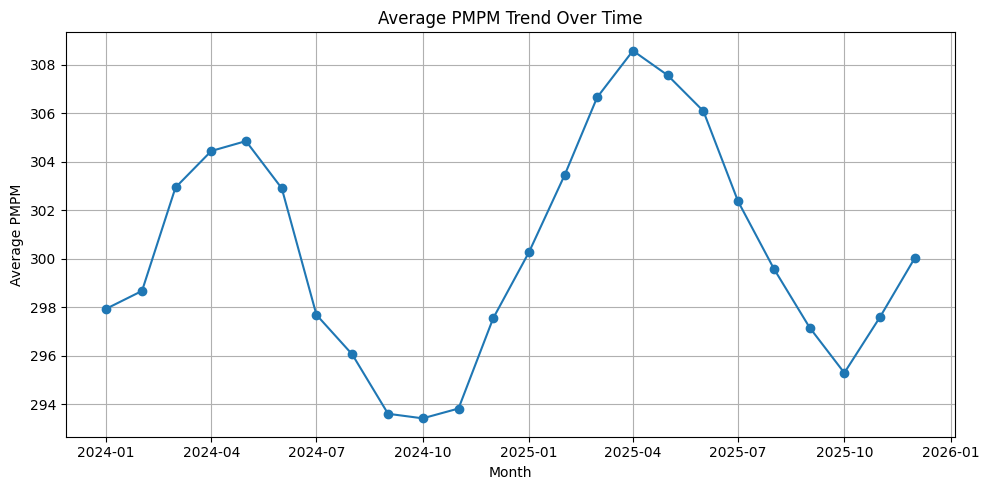

In [2]:
import pandas as pd
df = pd.read_csv('../data/healthcare_metrics.csv')
df.head()

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/healthcare_metrics.csv")

df["Month"] = pd.to_datetime(df["Month"])

monthly_pmpm = (
    df.groupby("Month")["PMPM"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(monthly_pmpm["Month"], monthly_pmpm["PMPM"], marker="o")

plt.title("Average PMPM Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Average PMPM")
plt.grid(True)

plt.tight_layout()
plt.show()

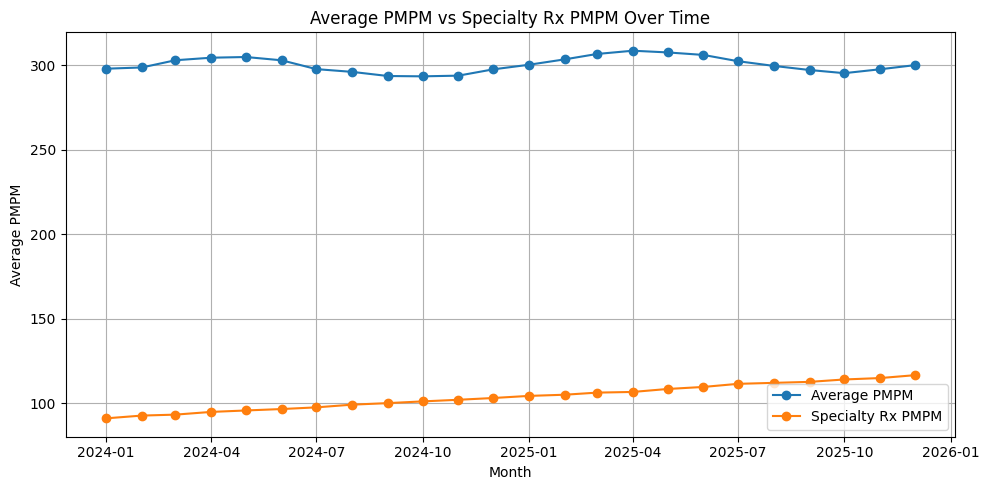

In [3]:
monthly_metrics = (
    df.groupby("Month", as_index=False)
      .agg({
          "PMPM": "mean",
          "Specialty_Rx_Spend_PMPM": "mean"
      })
)

monthly_metrics["Month"] = pd.to_datetime(monthly_metrics["Month"])
monthly_metrics = monthly_metrics.sort_values("Month")

plt.figure(figsize=(10, 5))
plt.plot(monthly_metrics["Month"], monthly_metrics["PMPM"], marker="o", label="Average PMPM")
plt.plot(monthly_metrics["Month"], monthly_metrics["Specialty_Rx_Spend_PMPM"], marker="o", label="Specialty Rx PMPM")

plt.title("Average PMPM vs Specialty Rx PMPM Over Time")
plt.xlabel("Month")
plt.ylabel("Average PMPM")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\sando\\Documents\\Python Scripts\\healthcare-cost-driver-evaluator\\notebooks\\images\\pmpm_cost_drivers.png'

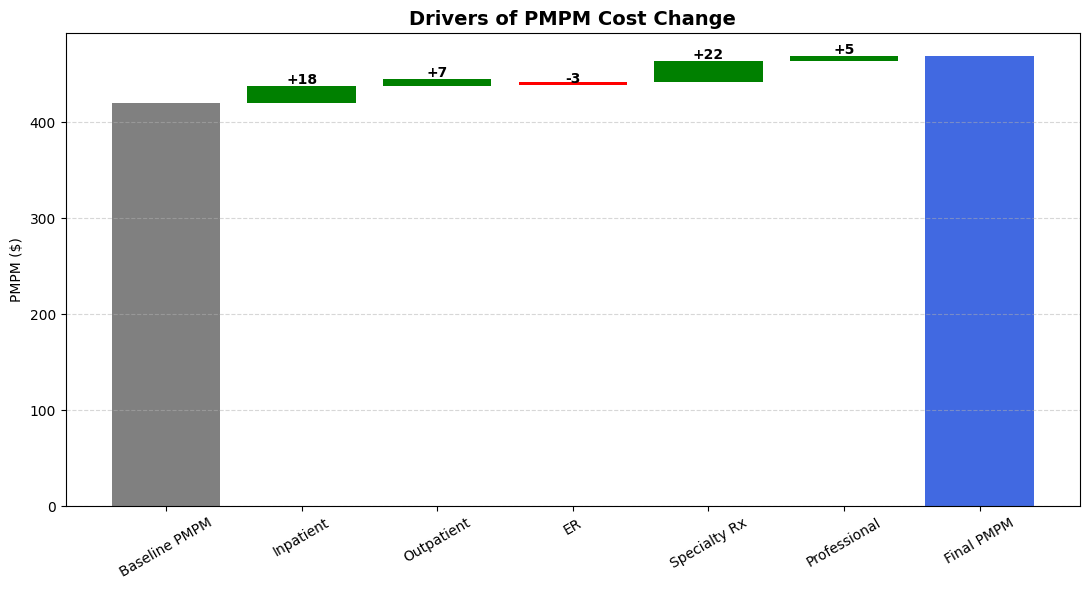

In [2]:
import matplotlib.pyplot as plt
import numpy as np

categories = [
    "Baseline PMPM",
    "Inpatient",
    "Outpatient",
    "ER",
    "Specialty Rx",
    "Professional",
    "Final PMPM"
]

values = [420, 18, 7, -3, 22, 5]

baseline = values[0]
drivers = values[1:]

running = baseline
bottoms = [0]
heights = [baseline]

for v in drivers:
    bottoms.append(running if v > 0 else running + v)
    heights.append(v)
    running += v

bottoms.append(0)
heights.append(running)

colors = [
    "gray",
    "green",
    "green",
    "red",
    "green",
    "green",
    "royalblue"
]

fig, ax = plt.subplots(figsize=(11,6))

bars = ax.bar(categories, heights, bottom=bottoms, color=colors)

# Add labels
for bar, val in zip(bars[1:-1], drivers):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_y() + bar.get_height() + 2,
        f"{val:+}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title("Drivers of PMPM Cost Change", fontsize=14, fontweight='bold')
ax.set_ylabel("PMPM ($)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("images/pmpm_cost_drivers.png", dpi=300)

plt.show()